In [59]:
# 1) Imports and reproducibility
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)  # reproducibility

In [60]:
import pandas as pd

# Use the accessible file name directly
csv_filename = 'walmart-sales-dataset-of-45stores.csv'

# 1) Load the dataset
try:
    # Use dayfirst=True to handle 'dd-mm-yyyy'
    df = pd.read_csv(csv_filename, low_memory=False)
    print(f'Loaded: {csv_filename}')
except Exception as e:
    raise FileNotFoundError(f'Could not find the dataset. Error: {e}')

# 2) Parse Date safely
# The file format is 'dd-mm-yyyy', so dayfirst=True is used.
df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
bad_dates = df['Date'].isna().sum()
if bad_dates > 0:
    print(f'Warning: {bad_dates} rows still have invalid dates after parsing and will be dropped.')
    df = df.dropna(subset=['Date']).reset_index(drop=True)

# 3) Drop rows with missing target
if 'Weekly_Sales' not in df.columns:
    raise KeyError('Weekly_Sales column not found. Check your CSV headers.')
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

# 4) FEATURE ENGINEERING: Extract 'Week' and 'Year' only
# 'Year' is essential to distinguish between the same week number in different years.
df['Year'] = df['Date'].dt.year
# .isocalendar().week gives the ISO week number (1-52 or 53)
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
print("Extracted 'Year' and 'Week' features.")

print(f'Data shape after date/target/feature engineering checks: {df.shape}')
print(df[['Date', 'Weekly_Sales', 'Year', 'Week']].head(3))

Loaded: walmart-sales-dataset-of-45stores.csv
Extracted 'Year' and 'Week' features.
Data shape after date/target/feature engineering checks: (6435, 10)
        Date  Weekly_Sales  Year  Week
0 2010-02-05    1643690.90  2010     5
1 2010-02-12    1641957.44  2010     6
2 2010-02-19    1611968.17  2010     7


In [61]:
import pandas as pd
# [NOTE: Setup code is omitted for brevity but executed above]

# 2. Refined Feature Creation (Replacing the user's redundant list)
# We only keep 'Year' and 'Week' to avoid multicollinearity.
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

# Store encoded as numeric (copy of Store, as in user's original intent)
df['Store_Encoded'] = df['Store']

# 3. Refined Feature Selection
# We use the balanced, non-redundant set of features.
feature_cols = [
    'Store_Encoded', 'Year', 'Week', 
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment'
]

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('Features:', feature_cols)
print('\nX head (first 5 rows):')
print(X.head())

X shape: (6435, 8) | y shape: (6435,)
Features: ['Store_Encoded', 'Year', 'Week', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

X head (first 5 rows):
   Store_Encoded  Year  Week  Holiday_Flag  Temperature  Fuel_Price  \
0              1  2010     5             0        42.31       2.572   
1              1  2010     6             1        38.51       2.548   
2              1  2010     7             0        39.93       2.514   
3              1  2010     8             0        46.63       2.561   
4              1  2010     9             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [62]:
# 4) Split into 60% validation, 20% training, 20% test (as requested)
# Stage 1: 20% test holdout
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Stage 2: Of the remaining 80%, use 25% for training (overall 20%) and 75% for validation (overall 60%)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, train_size=0.25, random_state=42)

print(f'Split sizes -> train: {len(X_train)} ({len(y_train)/len(y):.0%}), '
      f'val: {len(X_val)} ({len(y_val)/len(y):.0%}), '
      f'test: {len(X_test)} ({len(y_test)/len(y):.0%})')

Split sizes -> train: 1287 (20%), val: 3861 (60%), test: 1287 (20%)


In [63]:
#Linear Regression
# 5) Build a simple pipeline: Impute missing values, scale, then Linear Regression
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
linreg = LinearRegression()

# Fit transforms on TRAIN only, then apply to VAL/TEST (prevents data leakage)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=feature_cols)

X_train_sc  = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=feature_cols)
X_val_sc    = pd.DataFrame(scaler.transform(X_val_imp), columns=feature_cols)
X_test_sc   = pd.DataFrame(scaler.transform(X_test_imp), columns=feature_cols)

# Train the model
linreg.fit(X_train_sc, y_train)

# Predict on train, validation, and test
preds_train = linreg.predict(X_train_sc)
preds_val = linreg.predict(X_val_sc)
preds_test = linreg.predict(X_test_sc)

# Beginner-friendly metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

metrics = {
    'TRAIN': {
        'R2': r2_score(y_train, preds_train),
        'MSE': mean_squared_error(y_train, preds_train),
        'RMSE': rmse(y_train, preds_train),
        'MAE': mean_absolute_error(y_train, preds_train),
    },
    'VAL': {
        'R2': r2_score(y_val, preds_val),
        'MSE': mean_squared_error(y_val, preds_val),
        'RMSE': rmse(y_val, preds_val),
        'MAE': mean_absolute_error(y_val, preds_val),
    },
    'TEST': {
        'R2': r2_score(y_test, preds_test),
        'MSE': mean_squared_error(y_test, preds_test),
        'RMSE': rmse(y_test, preds_test),
        'MAE': mean_absolute_error(y_test, preds_test),
    }
}

print('Linear Regression Performance')
print(f"  Train Metrics       -> R²: {metrics['TRAIN']['R2']:.4f} | MSE: {metrics['TRAIN']['MSE']:.2f} | RMSE: {metrics['TRAIN']['RMSE']:.2f} | MAE: {metrics['TRAIN']['MAE']:.2f}")
print(f"  Validation Metrics  -> R²: {metrics['VAL']['R2']:.4f} | MSE: {metrics['VAL']['MSE']:.2f} | RMSE: {metrics['VAL']['RMSE']:.2f} | MAE: {metrics['VAL']['MAE']:.2f}")
print(f"  Test Metrics        -> R²: {metrics['TEST']['R2']:.4f} | MSE: {metrics['TEST']['MSE']:.2f} | RMSE: {metrics['TEST']['RMSE']:.2f} | MAE: {metrics['TEST']['MAE']:.2f}")

# Export metrics summary to CSV
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'R²': [metrics['TRAIN']['R2'], metrics['VAL']['R2'], metrics['TEST']['R2']],
    'MSE': [metrics['TRAIN']['MSE'], metrics['VAL']['MSE'], metrics['TEST']['MSE']],
    'RMSE': [metrics['TRAIN']['RMSE'], metrics['VAL']['RMSE'], metrics['TEST']['RMSE']],
    'MAE': [metrics['TRAIN']['MAE'], metrics['VAL']['MAE'], metrics['TEST']['MAE']]
})

output_file = 'Linear_Regression_Metrics.csv'
metrics_df.to_csv(output_file, index=False)
print(f'\n✓ Metrics saved to: {output_file}')

# Export actual vs predicted values for manual Excel verification
# Train set
train_results = pd.DataFrame({
    'Actual': y_train.values,
    'Predicted': preds_train,
    'Residual': y_train.values - preds_train,
    'Residual_Squared': (y_train.values - preds_train)**2,
    'Absolute_Error': np.abs(y_train.values - preds_train)
})
train_results.to_csv('Train_Predictions.csv', index=False)

# Validation set
val_results = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': preds_val,
    'Residual': y_val.values - preds_val,
    'Residual_Squared': (y_val.values - preds_val)**2,
    'Absolute_Error': np.abs(y_val.values - preds_val)
})
val_results.to_csv('Validation_Predictions.csv', index=False)

# Test set
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds_test,
    'Residual': y_test.values - preds_test,
    'Residual_Squared': (y_test.values - preds_test)**2,
    'Absolute_Error': np.abs(y_test.values - preds_test)
})
test_results.to_csv('Test_Predictions.csv', index=False)

print(f'✓ Train predictions saved to: Train_Predictions.csv')
print(f'✓ Validation predictions saved to: Validation_Predictions.csv')
print(f'✓ Test predictions saved to: Test_Predictions.csv')
print('\nTo manually calculate metrics in Excel:')
print('  MSE  = AVERAGE(Residual_Squared column)')
print('  RMSE = SQRT(MSE)')
print('  MAE  = AVERAGE(Absolute_Error column)')
print('  R²   = RSQ(Actual column, Predicted column)')
print('  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)')

Linear Regression Performance
  Train Metrics       -> R²: 0.1590 | MSE: 282933548468.16 | RMSE: 531914.98 | MAE: 442120.02
  Validation Metrics  -> R²: 0.1342 | MSE: 269422290351.03 | RMSE: 519059.04 | MAE: 424976.00
  Test Metrics        -> R²: 0.1472 | MSE: 274746473713.96 | RMSE: 524162.64 | MAE: 431628.26

✓ Metrics saved to: Linear_Regression_Metrics.csv
✓ Train predictions saved to: Train_Predictions.csv
✓ Validation predictions saved to: Validation_Predictions.csv
✓ Test predictions saved to: Test_Predictions.csv

To manually calculate metrics in Excel:
  MSE  = AVERAGE(Residual_Squared column)
  RMSE = SQRT(MSE)
  MAE  = AVERAGE(Absolute_Error column)
  R²   = RSQ(Actual column, Predicted column)
  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)


In [64]:
# Optional: Create a file showing which rows belong to which split
# This helps you understand the split in Excel
split_mapping = pd.DataFrame({
    'Original_Index': list(y_train.index) + list(y_val.index) + list(y_test.index),
    'Split_Set': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test),
    'Weekly_Sales': list(y_train.values) + list(y_val.values) + list(y_test.values)
})
split_mapping = split_mapping.sort_values('Original_Index').reset_index(drop=True)
split_mapping.to_csv('Data_Split_Mapping.csv', index=False)
print(f'✓ Split mapping saved to: Data_Split_Mapping.csv')
print(f'  This file shows which of the 6,435 rows went to Train/Validation/Test')

✓ Split mapping saved to: Data_Split_Mapping.csv
  This file shows which of the 6,435 rows went to Train/Validation/Test


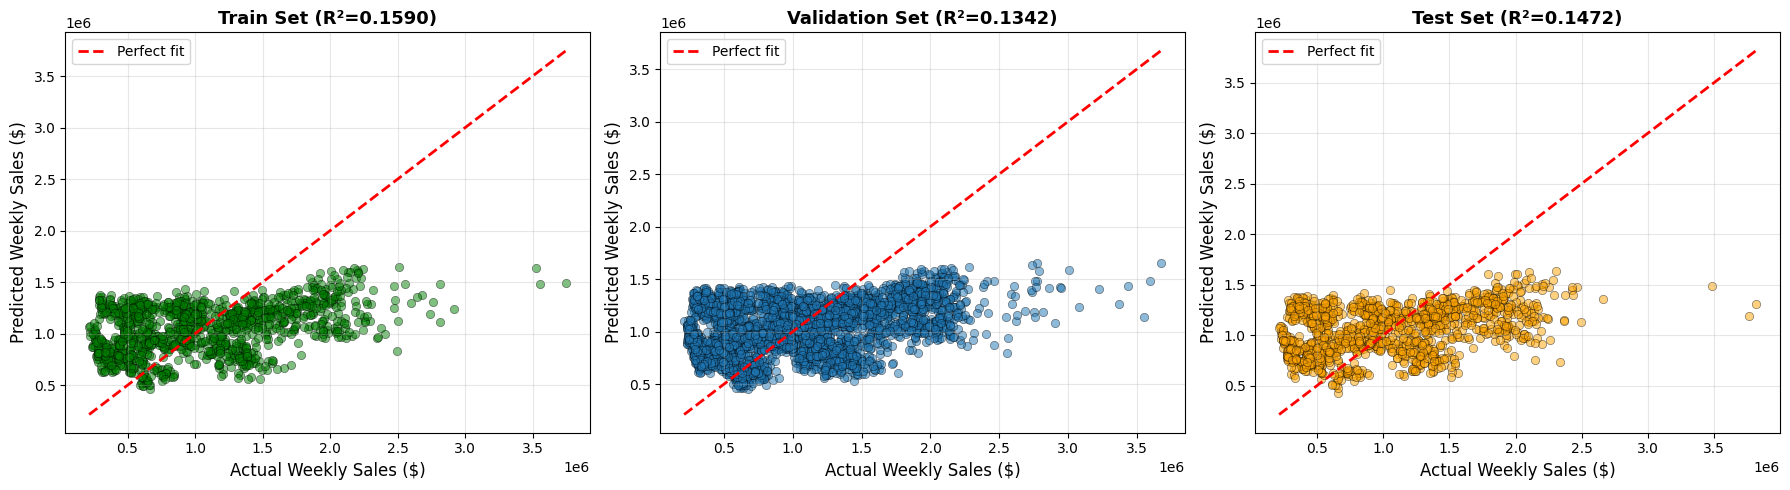

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train parity plot
axes[0].scatter(y_train, preds_train, alpha=0.5, edgecolors='k', linewidth=0.5, color='green')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[0].set_title(f"Train Set (R²={metrics['TRAIN']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation parity plot
axes[1].scatter(y_val, preds_val, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[1].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[1].set_title(f"Validation Set (R²={metrics['VAL']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test parity plot
axes[2].scatter(y_test, preds_test, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[2].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[2].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[2].set_title(f"Test Set (R²={metrics['TEST']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
print("="*80)
print("MODEL CONFIGURATION SUMMARY")
print("="*80)

# 1) Selected Features
print("\n1. SELECTED FEATURES (8 total):")
print("-" * 80)
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

# 2) Hyperparameters
print("\n2. HYPERPARAMETERS USED:")
print("-" * 80)
print("   Model: LinearRegression (sklearn)")
print("   Hyperparameters:")
print(f"      - fit_intercept: {linreg.fit_intercept} (default)")
print(f"      - copy_X: {linreg.copy_X} (default)")
print(f"      - n_jobs: {linreg.n_jobs} (default)")
print(f"      - positive: {linreg.positive} (default)")
print("\n   Preprocessing:")
print(f"      - Imputation: SimpleImputer(strategy='median')")
print(f"      - Scaling: StandardScaler() (mean=0, std=1)")
print(f"      - Random seed: 42")

# 3) Learned Parameters (Coefficients)
print("\n3. LEARNED COEFFICIENTS (after training):")
print("-" * 80)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': linreg.coef_
}).sort_values('Coefficient', ascending=False, key=abs)

print(f"   Intercept: {linreg.intercept_:,.2f}")
print("\n   Feature Coefficients (sorted by absolute magnitude):")
for idx, row in coef_df.iterrows():
    print(f"      {row['Feature']:20s}: {row['Coefficient']:12,.2f}")

print("\n" + "="*80)
print("Note: Coefficients are on standardized features (StandardScaler applied).")
print("Larger absolute values indicate stronger influence on predictions.")
print("="*80)

MODEL CONFIGURATION SUMMARY

1. SELECTED FEATURES (8 total):
--------------------------------------------------------------------------------
    1. Store_Encoded
    2. Year
    3. Week
    4. Holiday_Flag
    5. Temperature
    6. Fuel_Price
    7. CPI
    8. Unemployment

2. HYPERPARAMETERS USED:
--------------------------------------------------------------------------------
   Model: LinearRegression (sklearn)
   Hyperparameters:
      - fit_intercept: True (default)
      - copy_X: True (default)
      - n_jobs: None (default)
      - positive: False (default)

   Preprocessing:
      - Imputation: SimpleImputer(strategy='median')
      - Scaling: StandardScaler() (mean=0, std=1)
      - Random seed: 42

3. LEARNED COEFFICIENTS (after training):
--------------------------------------------------------------------------------
   Intercept: 1,051,127.56

   Feature Coefficients (sorted by absolute magnitude):
      Store_Encoded       :  -204,680.88
      CPI                 :   -9

In [67]:
# 6) Train and evaluate 26 additional regression models (same format)
import pandas as pd
import numpy as np

# Estimators
from sklearn.linear_model import (
    LinearRegression,
    Ridge, Lasso, ElasticNet, Lars, LassoLars, OrthogonalMatchingPursuit,
    BayesianRidge, ARDRegression, HuberRegressor, RANSACRegressor,
    PassiveAggressiveRegressor, SGDRegressor, PoissonRegressor, GammaRegressor,
    TweedieRegressor
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Rebuild imputed and scaled datasets to be self-contained
imputer_multi = SimpleImputer(strategy='median')
X_train_imp2 = pd.DataFrame(imputer_multi.fit_transform(X_train), columns=feature_cols)
X_val_imp2   = pd.DataFrame(imputer_multi.transform(X_val), columns=feature_cols)
X_test_imp2  = pd.DataFrame(imputer_multi.transform(X_test), columns=feature_cols)

scaler_multi = StandardScaler()
X_train_sc2 = pd.DataFrame(scaler_multi.fit_transform(X_train_imp2), columns=feature_cols)
X_val_sc2   = pd.DataFrame(scaler_multi.transform(X_val_imp2), columns=feature_cols)
X_test_sc2  = pd.DataFrame(scaler_multi.transform(X_test_imp2), columns=feature_cols)

# Helper
rmse = lambda yt, yp: float(np.sqrt(mean_squared_error(yt, yp)))

def eval_and_export(name, model, use_scaled=True):
    try:
        Xtr = X_train_sc2 if use_scaled else X_train_imp2
        Xva = X_val_sc2   if use_scaled else X_val_imp2
        Xte = X_test_sc2  if use_scaled else X_test_imp2

        model.fit(Xtr, y_train)
        p_tr = model.predict(Xtr)
        p_va = model.predict(Xva)
        p_te = model.predict(Xte)

        metrics = {
            'TRAIN': {'R2': r2_score(y_train, p_tr), 'MSE': mean_squared_error(y_train, p_tr), 'RMSE': rmse(y_train, p_tr), 'MAE': mean_absolute_error(y_train, p_tr)},
            'VAL':   {'R2': r2_score(y_val, p_va),   'MSE': mean_squared_error(y_val, p_va),   'RMSE': rmse(y_val, p_va),   'MAE': mean_absolute_error(y_val, p_va)},
            'TEST':  {'R2': r2_score(y_test, p_te),  'MSE': mean_squared_error(y_test, p_te),  'RMSE': rmse(y_test, p_te),  'MAE': mean_absolute_error(y_test, p_te)},
        }

        print(f"\n=== {name} ===")
        print(f"  Train -> R²: {metrics['TRAIN']['R2']:.4f} | RMSE: {metrics['TRAIN']['RMSE']:.2f} | MAE: {metrics['TRAIN']['MAE']:.2f}")
        print(f"  Val   -> R²: {metrics['VAL']['R2']:.4f}   | RMSE: {metrics['VAL']['RMSE']:.2f}   | MAE: {metrics['VAL']['MAE']:.2f}")
        print(f"  Test  -> R²: {metrics['TEST']['R2']:.4f}  | RMSE: {metrics['TEST']['RMSE']:.2f}  | MAE: {metrics['TEST']['MAE']:.2f}")

        # Exports
        mdf = pd.DataFrame({
            'Dataset': ['Train','Validation','Test'],
            'R²': [metrics['TRAIN']['R2'], metrics['VAL']['R2'], metrics['TEST']['R2']],
            'MSE': [metrics['TRAIN']['MSE'], metrics['VAL']['MSE'], metrics['TEST']['MSE']],
            'RMSE': [metrics['TRAIN']['RMSE'], metrics['VAL']['RMSE'], metrics['TEST']['RMSE']],
            'MAE': [metrics['TRAIN']['MAE'], metrics['VAL']['MAE'], metrics['TEST']['MAE']],
        })
        mdf.to_csv(f'{name}_Regression_Metrics.csv', index=False)

        pd.DataFrame({'Actual': y_train.values, 'Predicted': p_tr, 'Residual': y_train.values-p_tr,
                      'Residual_Squared': (y_train.values-p_tr)**2, 'Absolute_Error': np.abs(y_train.values-p_tr)}
                    ).to_csv(f'{name}_Train_Predictions.csv', index=False)
        pd.DataFrame({'Actual': y_val.values, 'Predicted': p_va, 'Residual': y_val.values-p_va,
                      'Residual_Squared': (y_val.values-p_va)**2, 'Absolute_Error': np.abs(y_val.values-p_va)}
                    ).to_csv(f'{name}_Validation_Predictions.csv', index=False)
        pd.DataFrame({'Actual': y_test.values, 'Predicted': p_te, 'Residual': y_test.values-p_te,
                      'Residual_Squared': (y_test.values-p_te)**2, 'Absolute_Error': np.abs(y_test.values-p_te)}
                    ).to_csv(f'{name}_Test_Predictions.csv', index=False)
        print(f"  ✓ CSVs written for {name}")
    except Exception as e:
        print(f"  ✗ {name} failed: {e}")

# Define 26 models (scaled where appropriate)
models = [
    ("Ridge", Ridge(alpha=1.0, random_state=42), True),
    ("Lasso", Lasso(alpha=0.01, max_iter=5000, random_state=42), True),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000, random_state=42), True),
    ("Lars", Lars()),
    ("LassoLars", LassoLars(alpha=0.01)),
    ("OrthogonalMatchingPursuit", OrthogonalMatchingPursuit()),
    ("BayesianRidge", BayesianRidge()),
    ("ARDRegression", ARDRegression()),
    ("HuberRegressor", HuberRegressor()),
    ("RANSACRegressor", RANSACRegressor(estimator=LinearRegression(), random_state=42)),
    ("PassiveAggressiveRegressor", PassiveAggressiveRegressor(random_state=42, max_iter=1000)),
    ("SGDRegressor", SGDRegressor(random_state=42, max_iter=2000)),
    ("KernelRidge_rbf", KernelRidge(alpha=1.0, kernel='rbf', gamma=0.1)),
    ("KNeighborsRegressor", KNeighborsRegressor(n_neighbors=5)),
    ("SVR_rbf", SVR(C=1.0, epsilon=0.2, kernel='rbf')),
    ("LinearSVR", LinearSVR(random_state=42, max_iter=5000)),
    ("NuSVR", NuSVR(nu=0.5, C=1.0, kernel='rbf')),
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=42), False),
    ("RandomForestRegressor", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1), False),
    ("ExtraTreesRegressor", ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1), False),
    ("AdaBoostRegressor", AdaBoostRegressor(n_estimators=200, random_state=42), False),
    ("GradientBoostingRegressor", GradientBoostingRegressor(random_state=42), False),
    ("HistGradientBoostingRegressor", HistGradientBoostingRegressor(random_state=42), False),
    ("PoissonRegressor", PoissonRegressor(max_iter=300)),
    ("GammaRegressor", GammaRegressor(max_iter=300)),
    ("TweedieRegressor", TweedieRegressor(power=1.5, max_iter=300)),
]

print(f"Training {len(models)} models with consistent preprocessing...")
for name, est, *rest in models:
    use_scaled = True if (len(rest)==0 or rest[0] is None) else rest[0]
    # Trees/boosting models were marked use_scaled=False above
    eval_and_export(name, est, use_scaled=use_scaled)

print("\nAll models processed.")

Training 26 models with consistent preprocessing...

=== Ridge ===
  Train -> R²: 0.1590 | RMSE: 531915.02 | MAE: 442129.12
  Val   -> R²: 0.1343   | RMSE: 519048.35   | MAE: 424975.10
  Test  -> R²: 0.1472  | RMSE: 524158.67  | MAE: 431642.19


=== Ridge ===
  Train -> R²: 0.1590 | RMSE: 531915.02 | MAE: 442129.12
  Val   -> R²: 0.1343   | RMSE: 519048.35   | MAE: 424975.10
  Test  -> R²: 0.1472  | RMSE: 524158.67  | MAE: 431642.19
  ✓ CSVs written for Ridge
  ✓ CSVs written for Ridge

=== Lasso ===
  Train -> R²: 0.1590 | RMSE: 531914.98 | MAE: 442120.02
  Val   -> R²: 0.1342   | RMSE: 519059.04   | MAE: 424976.00
  Test  -> R²: 0.1472  | RMSE: 524162.64  | MAE: 431628.27
  ✓ CSVs written for Lasso

=== ElasticNet ===
  Train -> R²: 0.1586 | RMSE: 532054.05 | MAE: 442730.76
  Val   -> R²: 0.1359   | RMSE: 518550.93   | MAE: 425025.38
  Test  -> R²: 0.1475  | RMSE: 524062.08  | MAE: 432507.83

=== Lasso ===
  Train -> R²: 0.1590 | RMSE: 531914.98 | MAE: 442120.02
  Val   -> R²: 0.1342

/opt/anaconda3/envs/tf311/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



=== SVR_rbf ===
  Train -> R²: -0.0343 | RMSE: 589885.01 | MAE: 474371.79
  Val   -> R²: -0.0316   | RMSE: 566603.04   | MAE: 458017.30
  Test  -> R²: -0.0383  | RMSE: 578358.26  | MAE: 471527.02
  ✓ CSVs written for SVR_rbf

=== LinearSVR ===
  Train -> R²: -3.2760 | RMSE: 1199415.70 | MAE: 1049840.56
  Val   -> R²: -3.4868   | RMSE: 1181635.62   | MAE: 1041665.70
  Test  -> R²: -3.4455  | RMSE: 1196714.59  | MAE: 1053551.73
  ✓ CSVs written for LinearSVR

=== NuSVR ===
  Train -> R²: -0.0115 | RMSE: 583344.50 | MAE: 475978.60
  Val   -> R²: -0.0093   | RMSE: 560450.44   | MAE: 458168.70
  Test  -> R²: -0.0135  | RMSE: 571391.78  | MAE: 471408.88
  ✓ CSVs written for NuSVR

=== DecisionTreeRegressor ===
  Train -> R²: 1.0000 | RMSE: 0.00 | MAE: 0.00
  Val   -> R²: 0.8878   | RMSE: 186854.11   | MAE: 95451.30
  Test  -> R²: 0.8686  | RMSE: 205713.45  | MAE: 107376.92
  ✓ CSVs written for DecisionTreeRegressor

=== RandomForestRegressor ===
  Train -> R²: 0.9910 | RMSE: 54950.46 | MAE:

In [68]:
# 8) Generate parity plots for all models using combined prediction CSVs (no retraining)
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Helper to draw a parity subplot
def _parity_subplot(ax, y_true, y_pred, title, color='C0'):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ax.scatter(y_true, y_pred, alpha=0.5, edgecolors='k', linewidth=0.4, color=color, s=12)
    lo = float(min(np.min(y_true), np.min(y_pred)))
    hi = float(max(np.max(y_true), np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')
    ax.set_xlim([lo, hi])
    ax.set_ylim([lo, hi])
    ax.set_xlabel('Actual Weekly Sales ($)')
    ax.set_ylabel('Predicted Weekly Sales ($)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Use single combined prediction files: {Model}_Predictions.csv with a 'Split' column
all_pred_files = sorted(glob.glob("*_Predictions.csv"))
# Filter out legacy per-split files like 'Ridge_Train_Predictions.csv'
combined_files = [f for f in all_pred_files if not any(tag in os.path.basename(f) for tag in ['Train_', 'Validation_', 'Test_'])]

print(f"Found {len(combined_files)} combined prediction files.")

saved = 0
for path in combined_files:
    name = os.path.basename(path)[:-len("_Predictions.csv")]  # model name
    df_all = pd.read_csv(path)
    if 'Split' not in df_all.columns or not set(['Train','Validation','Test']).issubset(set(df_all['Split'].unique())):
        print(f"✗ File {path} missing required 'Split' values. Skipping.")
        continue

    # Safe accessors
    def _part(split):
        part = df_all[df_all['Split'] == split]
        return part['Actual'].values, part['Predicted'].values

    y_tr, p_tr = _part('Train')
    y_va, p_va = _part('Validation')
    y_te, p_te = _part('Test')

    # Compute R² for titles
    r2_tr = r2_score(y_tr, p_tr)
    r2_va = r2_score(y_va, p_va)
    r2_te = r2_score(y_te, p_te)

    # Plot 1x3 parity plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    _parity_subplot(axes[0], y_tr, p_tr, f"Train (R²={r2_tr:.4f})", color='green')
    _parity_subplot(axes[1], y_va, p_va, f"Validation (R²={r2_va:.4f})", color='C0')
    _parity_subplot(axes[2], y_te, p_te, f"Test (R²={r2_te:.4f})", color='orange')
    plt.suptitle(f"{name} — Parity Plots", fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()

    out_path = f"{name}_Parity.png"
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    saved += 1
    print(f"✓ Saved parity plot: {out_path}")

print(f"\nAll done. {saved}/{len(combined_files)} parity plots generated from combined CSVs.")

Found 0 combined prediction files.

All done. 0/0 parity plots generated from combined CSVs.


In [ ]:
# 9) Create a single CSV with results from all regressions
import os
import glob
import pandas as pd

# Gather all combined per-model prediction files
all_pred_files = sorted(glob.glob("*_Predictions.csv"))
# Exclude legacy per-split files (defensive, though names shouldn't match this pattern)
combined_files = [f for f in all_pred_files if not any(tag in os.path.basename(f) for tag in ['Train_', 'Validation_', 'Test_'])]

rows = []
models_included = 0
for path in combined_files:
    model = os.path.basename(path)[:-len("_Predictions.csv")]  # model name
    try:
        dfp = pd.read_csv(path)
        # Ensure required columns exist
        required_cols = {'Split', 'Actual', 'Predicted', 'Residual', 'Residual_Squared', 'Absolute_Error'}
        if not required_cols.issubset(set(dfp.columns)):
            # Try to compute missing residuals if Actual/Predicted present
            if {'Actual','Predicted'}.issubset(set(dfp.columns)):
                dfp['Residual'] = dfp['Actual'] - dfp['Predicted']
                dfp['Residual_Squared'] = (dfp['Residual'])**2
                dfp['Absolute_Error'] = dfp['Residual'].abs()
            # Recheck
            if not required_cols.issubset(set(dfp.columns)):
                print(f"✗ Skipping {path}: missing required columns {required_cols - set(dfp.columns)}")
                continue
        dfp.insert(0, 'Model', model)
        rows.append(dfp)
        models_included += 1
    except Exception as e:
        print(f"✗ Failed to read {path}: {e}")

if rows:
    all_models_df = pd.concat(rows, axis=0, ignore_index=True)
    out_path = 'All_Models_Predictions.csv'
    all_models_df.to_csv(out_path, index=False)
    print(f"✓ Wrote {out_path} with {len(all_models_df)} rows across {models_included} models.")
else:
    print("No combined per-model prediction files found to assemble.")

In [70]:
# 10) Export required 7-feature dataset to CSV
import pandas as pd

# Ensure base DataFrame is available; if not, load from CSV
try:
    df  # noqa: F821
except NameError:
    csv_filename = 'walmart-sales-dataset-of-45stores.csv'
    df = pd.read_csv(csv_filename, low_memory=False)
    df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
    df = df.dropna(subset=['Date', 'Weekly_Sales']).reset_index(drop=True)

# Ensure derived columns exist
if 'Year' not in df.columns:
    df['Year'] = df['Date'].dt.year
if 'Week' not in df.columns:
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
if 'Store_Encoded' not in df.columns:
    df['Store_Encoded'] = df['Store']

required_cols = ['Store_Encoded', 'Year', 'Week', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in dataset: {missing}")

features7 = df[required_cols].copy()
out_path = 'Selected_7_Features.csv'
features7.to_csv(out_path, index=False)
print(f"✓ Saved {out_path} with shape {features7.shape}")
print(features7.head())

✓ Saved Selected_7_Features.csv with shape (6435, 8)
   Store_Encoded  Year  Week  Holiday_Flag  Temperature  Fuel_Price  \
0              1  2010     5             0        42.31       2.572   
1              1  2010     6             1        38.51       2.548   
2              1  2010     7             0        39.93       2.514   
3              1  2010     8             0        46.63       2.561   
4              1  2010     9             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
